# Fase dos: qué le hicieron los modelos entrenados a su representación

La fase uno dice qué método gana. No dice si ganó **alineando los dominios clase
por clase**, que es lo que las dos formulaciones afirman. Esa afirmación vive en
la representación, así que se mide ahí.

Este cuaderno no entrena nada. Carga los checkpoints que guardó la fase uno y lee
qué representan — que es lo que hace barata cualquier pregunta posterior: todo lo
que se pueda calcular a partir de pesos y datos se puede agregar cuando se le
ocurra a alguien, sin volver a correr la campaña.

Dos reglas gobiernan cada figura de abajo, y las dos existen para que un dibujo no
salga más lindo que la corrida que describe.

**Una sola semilla de exhibición, no la mediana de cada método.** Paneles sacados
de semillas distintas se diferenciarían en el método *y* en el sorteo, y como la
semilla fija la partición, ni siquiera compartirían las bolsas. La semilla se
elige con una regla que no favorece a nadie: aquella cuya exactitud media
**sobre todos los métodos** es la mediana.

**Artefactos medianos, nunca el mejor.** El mejor de N crece con la dispersión
propia del método, así que comparar mejor contra mejor le hace el regalo más
grande al método más ruidoso.

In [1]:
import os
import sys
from pathlib import Path


def find_repository() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in (os.environ.get("MIL_CREDA_REPO", ""), "/content", "/kaggle/working"):
        if base and Path(base).is_dir():
            candidates.append(Path(base))
            candidates.extend(sorted(Path(base).glob("*")))
    for candidate in candidates:
        if (candidate / "src" / "MIL_CREDA_Benchmark").is_dir():
            return candidate.resolve()
    raise SystemExit(
        "cannot find the repository. Set MIL_CREDA_REPO to the checkout that "
        "holds src/MIL_CREDA_Benchmark, or run this notebook from inside it."
    )


REPOSITORY = find_repository()
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [2]:
import json

import torch
from IPython.display import Markdown, display

from MIL_CREDA_Benchmark import config, figures, harness, latent, tables


def show(text: str) -> None:
    """Una tabla se muestra como tabla, no como texto de ancho fijo.

    Es la misma cadena que va al registro, renderizada. Nada se vuelve a calcular
    acá: si esto y el archivo dijeran cosas distintas, habría dos versiones del
    mismo número y ninguna forma de saber cuál se movió.
    """
    display(Markdown(text))


device = harness.resolve_device()
found = latent.available()
if not found:
    raise SystemExit(
        f"no hay checkpoints en {config.MODELS}. Corré primero la fase uno: guarda "
        f"las repeticiones más cercanas a la mediana de cada celda."
    )

runs = [json.loads(line) for line in
        (config.RESULTS / "runs.jsonl").read_text().splitlines() if line.strip()]
summary = json.loads((config.RESULTS / "summary.json").read_text())
seed = latent.display_seed(runs)
print(f"{len(found)} checkpoints en {device} · semilla de exhibición: {seed}")

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


60 checkpoints en mps · semilla de exhibición: 0


In [3]:
readings = [latent.analyse(record, device) for record in found]
print(f"{len(readings)} checkpoints medidos")

60 checkpoints medidos


## Bajo qué corrió todo esto

Los límites de la corrida se dicen una vez, acá, y atan todo lo que sigue. No se
repiten en cada tabla: un aviso que aparece ocho veces enseña a saltearlo, y la vez
que importaba era una de esas ocho.

In [4]:
show(tables.stamp(summary["reduction"], markdown=True))

> resnet18  ·  3 épocas  ·  1 repetición(es)  ·  research-concept-r16.md  
> la exactitud se mueve de a 2.78 puntos sobre 36 bolsas de evaluación: nada por debajo de eso lo resuelve una transferencia sola  
> !! 1 repetición(es): el ± de abajo es cero por construcción, no por acuerdo. Son estimaciones puntuales, no resultados.  
> !! piloto: el protocolo declara 30 repeticiones y 20 épocas. Nada de esto es un resultado.  

## 1 · ¿Son redundantes los dos pisos?

`Baseline` y `MIL-Baseline` no aprenden ninguna adaptación: los dos son el mismo
modelo sin término, uno midiendo sobre instancias y el otro sobre bolsas. Medimos
si su representación coincide —la razón entre distancias y la separabilidad de
dominio, transferencia por transferencia— para decidir si la grilla de abajo lleva
dos columnas de piso o una. Buscamos que la diferencia entre ambos sea menor que la
que separa a cualquiera de ellos de un método con adaptación: si lo es, la segunda
columna no aporta nada que la primera no muestre, y ocupa espacio que sí importa.

La decisión la toma la medición, no el gusto: el código compara y colapsa solo si
encontró que hay algo que colapsar.

In [5]:
show(tables.objective("floors"))

> **Buscamos que la diferencia entre los dos pisos sea menor que la que los separa de cualquier método con adaptación.** Si lo es, la segunda columna no muestra nada que la primera no muestre y se colapsa.

In [6]:
transfers = tables.best_transfers(runs)
pisos = latent.floors_agree(transfers, seed, device)
for fila in pisos["byTransfer"]:
    print(f"  {fila['transfer']:<7} razón A={fila['ratio']['A']:.3f} "
          f"B={fila['ratio']['B']:.3f} (dif {fila['ratioGap']:.3f})   "
          f"separab. A={fila['separability']['A']:.3f} "
          f"B={fila['separability']['B']:.3f} (dif {fila['separabilityGap']:.3f})")

paneles = ([a for a in config.LATENT_PANELS if a != "B"] if pisos["agree"]
           else config.LATENT_PANELS)

  U->M    razón A=0.530 B=0.673 (dif 0.143)   separab. A=0.851 B=0.921 (dif 0.070)
  M->U    razón A=0.598 B=0.979 (dif 0.381)   separab. A=0.930 B=0.989 (dif 0.059)
  S->M    razón A=1.474 B=1.518 (dif 0.044)   separab. A=0.994 B=0.997 (dif 0.004)


In [7]:
show(pisos["detail"])

Baseline y MIL-Baseline NO representan lo mismo a nivel de instancia: la razón entre distancias difiere hasta 0.381 y la separabilidad hasta 0.070, contra una tolerancia de 0.05. Sacar una de las dos columnas pierde el piso de esa familia.

## 2 · La grilla del espacio de representación

Cada panel es el espacio donde cada método dejó a sus datos, con las filas por
transferencia y las columnas por método. El color es la clase, los círculos son la
fuente y los triángulos el destino. Buscamos que los dos dominios se mezclen dentro
de cada clase y que las clases sigan separadas entre sí: mezclar todo también junta
los dominios, y eso no es alinear sino colapsar.

Cada panel se dibuja al nivel de instancia, entrene el método sobre instancias o
sobre bolsas, porque es el único espacio que todos tienen y el único modo de que
todos los paneles lleven la misma cantidad de puntos. Un panel más denso que otro se
lee como más cobertura, y sería la unidad estadística dibujada y no la alineación.
Todos los paneles de una fila miran los mismos sujetos.

In [8]:
show(tables.objective("grid"))

> **Buscamos que los dos dominios se mezclen dentro de cada clase y que las clases sigan separadas entre sí.** Mezclar todo también junta los dominios, y eso no es alinear sino colapsar.

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


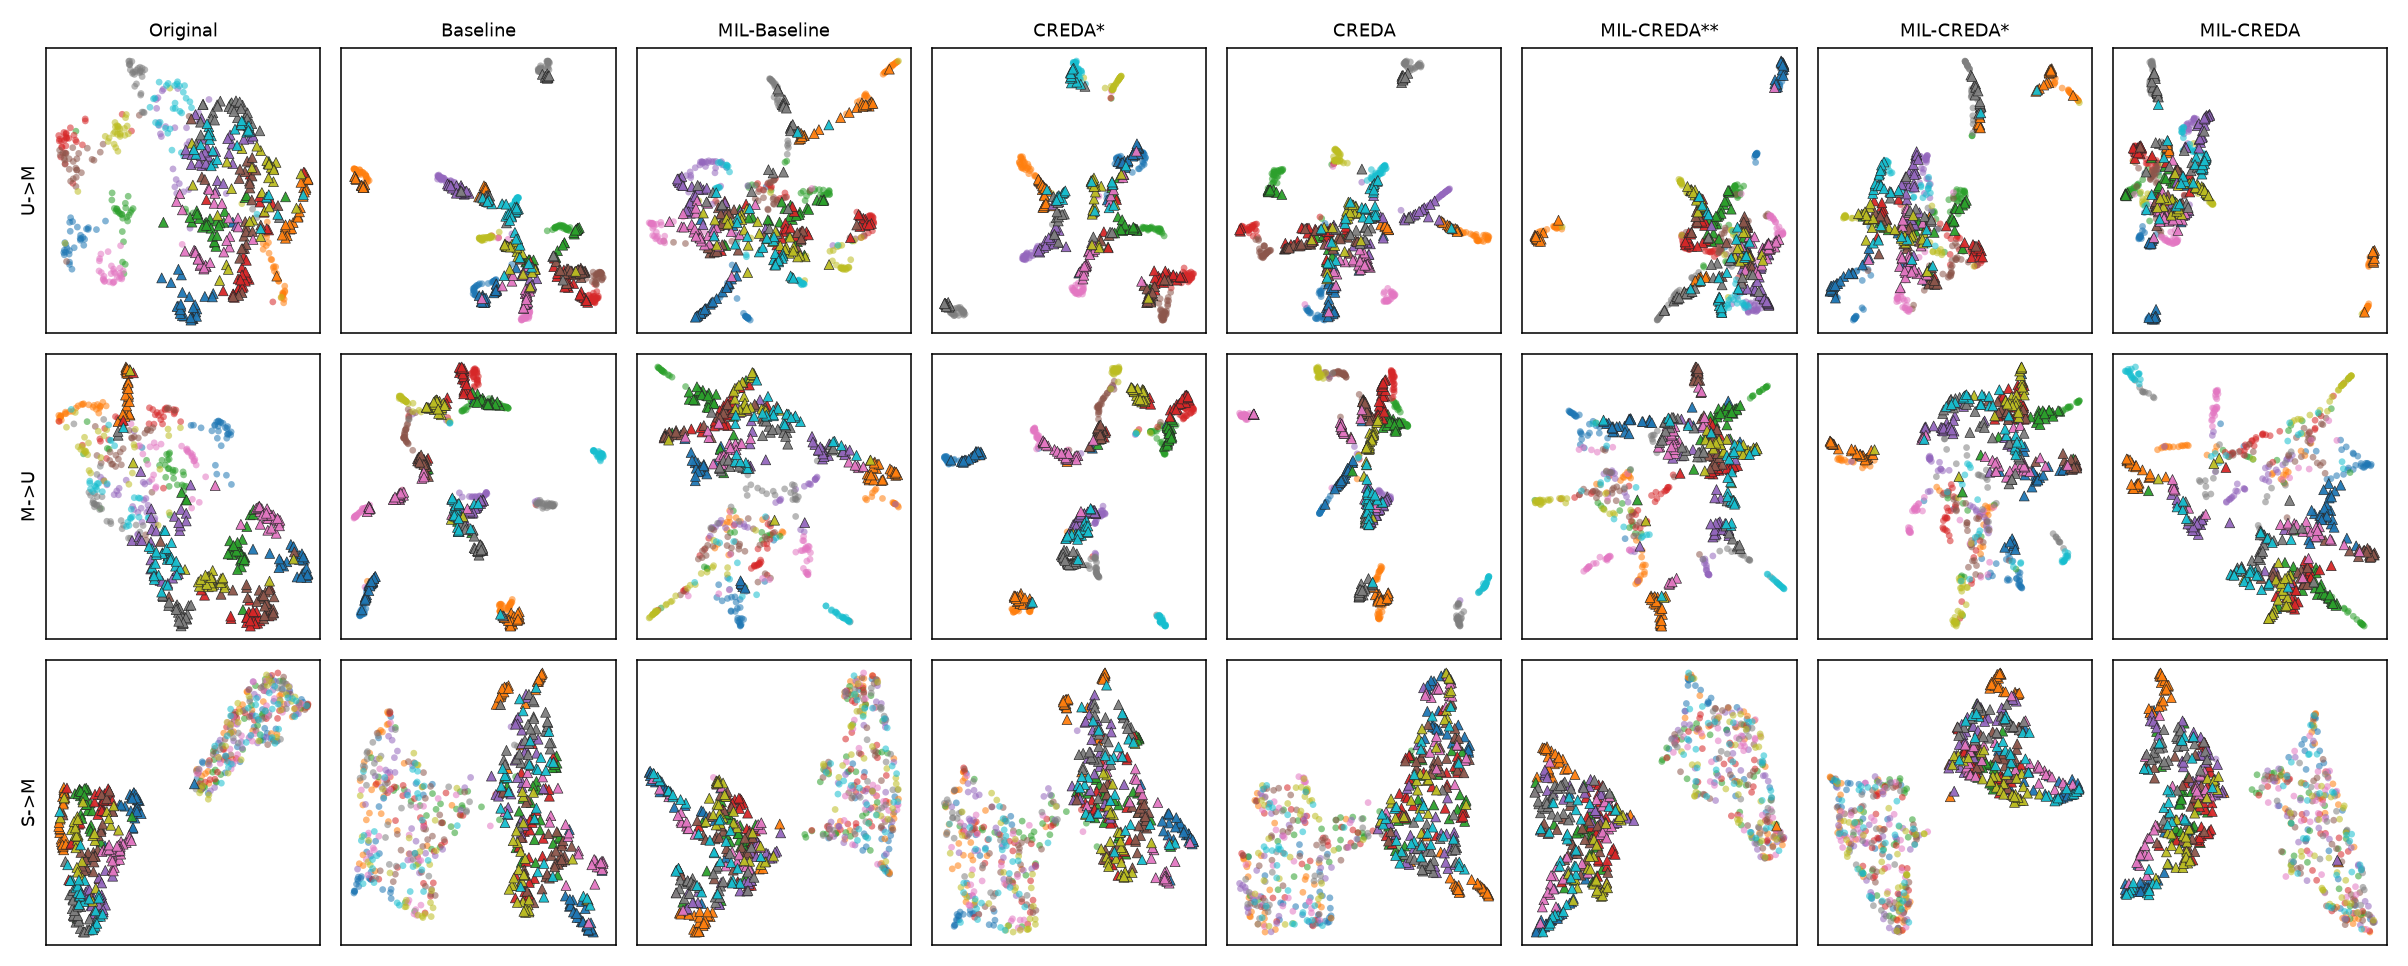

In [9]:
grid_path = config.RESULTS / "latent" / "grid.pdf"
display(figures.inline(latent.latent_grid(grid_path, paneles, transfers, seed, device)))

## 3 · La razón entre distancias

Cuánto se acercaron los dominios sin que las clases se acercaran entre sí: la
distancia media entre los centroides de la misma clase en los dos dominios, dividida
por la distancia media entre clases distintas dentro de un dominio. Es el número que
pone cifras a lo que la grilla de arriba deja ver. Buscamos que baje, **pero solo
sirve leída junto con su denominador**: una razón puede caer porque los dominios se
acercaron o porque todo colapsó, y sola llama éxito a las dos cosas. Por eso las dos
distancias van por separado justo abajo.

In [10]:
show(tables.objective("geometry.ratio"))

> **Buscamos que tienda a cero**, y solo vale si el denominador se sostiene: por debajo de 1.000 la misma clase está más junta entre dominios que dos clases distintas dentro de uno, que es lo que se quiere. Pero una razón también cae si todo colapsa.

In [11]:
show(tables.render_readings(readings, "geometry.ratio",
                            "razón: misma clase entre dominios / entre clases",
                            markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 0.598 ± 0.000 | 0.530 ± 0.000 | 1.205 ± 0.000 | 1.474 ± 0.000 | 1.205 ± 0.000 | 1.320 ± 0.000 | **1.055** |
| `CREDA*` | 0.586 ± 0.000 | 0.555 ± 0.000 | 1.230 ± 0.000 | 1.521 ± 0.000 | 1.195 ± 0.000 | 1.343 ± 0.000 | **1.071** |
| `CREDA` | 0.691 ± 0.000 | 0.672 ± 0.000 | 1.218 ± 0.000 | 1.780 ± 0.000 | 1.244 ± 0.000 | 1.451 ± 0.000 | **1.176** |
| `MIL-Baseline` | 0.961 ± 0.000 | 0.579 ± 0.000 | 1.175 ± 0.000 | 1.171 ± 0.000 | 1.138 ± 0.000 | 1.066 ± 0.000 | **1.015** |
| `MIL-CREDA**` | 0.821 ± 0.000 | 0.499 ± 0.000 | 1.140 ± 0.000 | 1.189 ± 0.000 | 1.181 ± 0.000 | 1.072 ± 0.000 | **0.984** |
| `MIL-CREDA*` | 0.815 ± 0.000 | 0.521 ± 0.000 | 1.134 ± 0.000 | 1.180 ± 0.000 | 1.223 ± 0.000 | 1.039 ± 0.000 | **0.985** |
| `MIL-CREDA` | 0.887 ± 0.000 | 0.455 ± 0.000 | 1.181 ± 0.000 | 1.192 ± 0.000 | 1.227 ± 0.000 | 1.104 ± 0.000 | **1.008** |
| `MIL-CREDA-U` | 1.160 ± 0.000 | 0.671 ± 0.000 | 1.347 ± 0.000 | 1.243 ± 0.000 | 1.246 ± 0.000 | 1.239 ± 0.000 | **1.151** |
| `MIL-CREDA-A` | 0.874 ± 0.000 | 0.752 ± 0.000 | 1.259 ± 0.000 | 1.740 ± 0.000 | 1.291 ± 0.000 | 1.150 ± 0.000 | **1.178** |
| `MIL-CREDA-K` | 0.835 ± 0.000 | 0.683 ± 0.000 | 1.191 ± 0.000 | 1.580 ± 0.000 | 1.188 ± 0.000 | 1.179 ± 0.000 | **1.109** |

In [12]:
show(tables.conclusion_geometry(readings))

Cada método contra su propio piso, transferencia por transferencia. «Alinea» = la razón bajó; «colapsa» = la razón no bajó y la distancia entre clases cayó más del 10%.

Método        piso            alinea  plano  empeora  colapsa
CREDA         Baseline             0      1        5        3
MIL-CREDA     MIL-Baseline         2      1        3        4
MIL-CREDA*    MIL-Baseline         4      1        1        2
MIL-CREDA**   MIL-Baseline         3      2        1        2
MIL-CREDA-U   MIL-Baseline         0      0        6        4
MIL-CREDA-A   MIL-Baseline         1      0        5        5
MIL-CREDA-K   MIL-Baseline         1      1        4        5
CREDA*        Baseline             0      2        4        1

Lo que carga peso no es el promedio sino que las transferencias coincidan: un método que alinea en una y empeora en otra no está diciendo nada todavía.
Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

### 3b · Las dos distancias por separado

Los dos numeradores de la razón anterior, cada uno en su tabla porque cada tabla es
una medición: primero la distancia de una misma clase **entre los dos dominios**,
que es lo que la adaptación tendría que estar acercando; después la distancia
**entre clases distintas dentro de un dominio**, que es lo que no debería moverse.

Van juntas y se concluyen juntas, y eso no es una comodidad de formato. La primera
bajando puede ser alineación o puede ser colapso, y sola llama éxito a las dos
cosas; lo que las distingue es si la segunda bajó con ella. Buscamos que la primera
caiga y la segunda se sostenga. Una conclusión sobre cualquiera de las dos por
separado estaría leyendo media razón.

In [13]:
show(tables.objective("geometry.distances"))

> **Buscamos que la primera caiga y la segunda se sostenga.** Si las dos bajan juntas, la razón de arriba mejoró por degeneración; el par es lo único que distingue alinear de colapsar.

In [14]:
show(tables.render_readings(readings, "geometry.crossDomainSameClass",
                            "misma clase, entre los dos dominios", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 19.011 ± 0.000 | 17.595 ± 0.000 | 27.487 ± 0.000 | 17.856 ± 0.000 | 31.137 ± 0.000 | 18.449 ± 0.000 | **21.922** |
| `CREDA*` | 18.060 ± 0.000 | 17.418 ± 0.000 | 25.121 ± 0.000 | 18.287 ± 0.000 | 28.046 ± 0.000 | 18.375 ± 0.000 | **20.885** |
| `CREDA` | 20.147 ± 0.000 | 19.653 ± 0.000 | 29.423 ± 0.000 | 17.541 ± 0.000 | 32.647 ± 0.000 | 15.486 ± 0.000 | **22.483** |
| `MIL-Baseline` | 36.729 ± 0.000 | 22.070 ± 0.000 | 46.951 ± 0.000 | 34.710 ± 0.000 | 34.522 ± 0.000 | 37.978 ± 0.000 | **35.493** |
| `MIL-CREDA**` | 27.433 ± 0.000 | 17.519 ± 0.000 | 33.541 ± 0.000 | 26.888 ± 0.000 | 32.890 ± 0.000 | 33.181 ± 0.000 | **28.575** |
| `MIL-CREDA*` | 29.132 ± 0.000 | 16.961 ± 0.000 | 34.971 ± 0.000 | 27.821 ± 0.000 | 32.938 ± 0.000 | 30.480 ± 0.000 | **28.717** |
| `MIL-CREDA` | 28.244 ± 0.000 | 14.845 ± 0.000 | 34.405 ± 0.000 | 27.028 ± 0.000 | 31.031 ± 0.000 | 29.627 ± 0.000 | **27.530** |
| `MIL-CREDA-U` | 29.386 ± 0.000 | 24.053 ± 0.000 | 26.726 ± 0.000 | 18.670 ± 0.000 | 36.375 ± 0.000 | 16.349 ± 0.000 | **25.260** |
| `MIL-CREDA-A` | 28.447 ± 0.000 | 22.947 ± 0.000 | 30.975 ± 0.000 | 15.355 ± 0.000 | 28.521 ± 0.000 | 15.846 ± 0.000 | **23.682** |
| `MIL-CREDA-K` | 31.415 ± 0.000 | 20.522 ± 0.000 | 28.805 ± 0.000 | 23.212 ± 0.000 | 24.193 ± 0.000 | 22.764 ± 0.000 | **25.152** |

In [15]:
show(tables.render_readings(readings, "geometry.betweenClasses",
                            "clases distintas, dentro de un dominio", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 31.803 ± 0.000 | 33.181 ± 0.000 | 22.816 ± 0.000 | 12.117 ± 0.000 | 25.847 ± 0.000 | 13.974 ± 0.000 | **23.290** |
| `CREDA*` | 30.844 ± 0.000 | 31.378 ± 0.000 | 20.431 ± 0.000 | 12.023 ± 0.000 | 23.474 ± 0.000 | 13.686 ± 0.000 | **21.973** |
| `CREDA` | 29.160 ± 0.000 | 29.241 ± 0.000 | 24.154 ± 0.000 | 9.853 ± 0.000 | 26.251 ± 0.000 | 10.673 ± 0.000 | **21.555** |
| `MIL-Baseline` | 38.205 ± 0.000 | 38.125 ± 0.000 | 39.948 ± 0.000 | 29.649 ± 0.000 | 30.323 ± 0.000 | 35.615 ± 0.000 | **35.311** |
| `MIL-CREDA**` | 33.405 ± 0.000 | 35.135 ± 0.000 | 29.434 ± 0.000 | 22.617 ± 0.000 | 27.851 ± 0.000 | 30.952 ± 0.000 | **29.899** |
| `MIL-CREDA*` | 35.737 ± 0.000 | 32.583 ± 0.000 | 30.828 ± 0.000 | 23.569 ± 0.000 | 26.926 ± 0.000 | 29.343 ± 0.000 | **29.831** |
| `MIL-CREDA` | 31.833 ± 0.000 | 32.645 ± 0.000 | 29.124 ± 0.000 | 22.680 ± 0.000 | 25.286 ± 0.000 | 26.841 ± 0.000 | **28.068** |
| `MIL-CREDA-U` | 25.335 ± 0.000 | 35.837 ± 0.000 | 19.846 ± 0.000 | 15.024 ± 0.000 | 29.196 ± 0.000 | 13.193 ± 0.000 | **23.072** |
| `MIL-CREDA-A` | 32.534 ± 0.000 | 30.522 ± 0.000 | 24.610 ± 0.000 | 8.824 ± 0.000 | 22.094 ± 0.000 | 13.778 ± 0.000 | **22.060** |
| `MIL-CREDA-K` | 37.635 ± 0.000 | 30.029 ± 0.000 | 24.177 ± 0.000 | 14.689 ± 0.000 | 20.371 ± 0.000 | 19.310 ± 0.000 | **24.368** |

In [16]:
show(tables.conclusion_distances(readings))

CREDA contra Baseline: misma clase entre dominios +2.0%, clases distintas -9.2% sobre 6 transferencia(s) — las clases se juntaron entre sí más que la misma clase entre dominios. MIL-CREDA contra MIL-Baseline: misma clase entre dominios -22.8%, clases distintas -20.5% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. MIL-CREDA* contra MIL-Baseline: misma clase entre dominios -18.9%, clases distintas -15.5% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. MIL-CREDA** contra MIL-Baseline: misma clase entre dominios -19.1%, clases distintas -15.3% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. MIL-CREDA-U contra MIL-Baseline: misma clase entre dominios -25.3%, clases distintas -34.3% sobre 6 transferencia(s) — las clases se juntaron entre sí más que la misma clase entre dominios. MIL-CREDA-A contra MIL-Baseline: misma clase entre dominios -30.7%, clases distintas -38.6% sobre 6 transferencia(s) — las clases se juntaron entre sí más que la misma clase entre dominios. MIL-CREDA-K contra MIL-Baseline: misma clase entre dominios -27.2%, clases distintas -31.9% sobre 6 transferencia(s) — las clases se juntaron entre sí más que la misma clase entre dominios. CREDA* contra Baseline: misma clase entre dominios -3.8%, clases distintas -5.2% sobre 6 transferencia(s) — las clases se juntaron entre sí más que la misma clase entre dominios. Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

## 4 · Qué tan separables siguen los dominios

Con qué exactitud una regla lineal entrenada sobre la representación puede decir de
qué dominio vino cada punto. Es la lectura complementaria de la anterior: mide si
quedó información de dominio, que es justo lo que la adaptación tendría que haber
borrado. Buscamos que se acerque al azar de esa decisión —que son dos etiquetas, así
que 0.5— y no que baje todo lo posible: por debajo del azar la regla estaría
acertando al revés, que es otra forma de decir que la información sigue ahí.

In [17]:
show(tables.objective("domainSeparability"))

> **Buscamos que se acerque a 0.500**, que es el azar de decidir entre dos dominios. No más bajo: por debajo del azar la regla acierta al revés, que es otra forma de decir que la información de dominio sigue ahí. Un 1.000 es un dominio perfectamente reconocible.

In [18]:
show(tables.render_readings(readings, "domainSeparability",
                            f"exactitud de un clasificador de dominio "
                            f"(azar {tables.DOMAIN_CHANCE:.3f})", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 0.930 ± 0.000 | 0.851 ± 0.000 | 0.947 ± 0.000 | 0.994 ± 0.000 | 0.894 ± 0.000 | 0.981 ± 0.000 | **0.933** |
| `CREDA*` | 0.921 ± 0.000 | 0.876 ± 0.000 | 0.954 ± 0.000 | 0.992 ± 0.000 | 0.887 ± 0.000 | 0.974 ± 0.000 | **0.934** |
| `CREDA` | 0.942 ± 0.000 | 0.901 ± 0.000 | 0.970 ± 0.000 | 0.994 ± 0.000 | 0.954 ± 0.000 | 0.986 ± 0.000 | **0.958** |
| `MIL-Baseline` | 0.890 ± 0.000 | 0.792 ± 0.000 | 0.847 ± 0.000 | 0.986 ± 0.000 | 0.890 ± 0.000 | 0.960 ± 0.000 | **0.894** |
| `MIL-CREDA**` | 0.890 ± 0.000 | 0.806 ± 0.000 | 0.819 ± 0.000 | 1.000 ± 0.000 | 0.903 ± 0.000 | 1.000 ± 0.000 | **0.903** |
| `MIL-CREDA*` | 0.863 ± 0.000 | 0.821 ± 0.000 | 0.848 ± 0.000 | 1.000 ± 0.000 | 0.903 ± 0.000 | 1.000 ± 0.000 | **0.906** |
| `MIL-CREDA` | 0.890 ± 0.000 | 0.848 ± 0.000 | 0.875 ± 0.000 | 1.000 ± 0.000 | 0.930 ± 0.000 | 1.000 ± 0.000 | **0.924** |
| `MIL-CREDA-U` | 0.931 ± 0.000 | 0.805 ± 0.000 | 0.918 ± 0.000 | 1.000 ± 0.000 | 0.960 ± 0.000 | 0.960 ± 0.000 | **0.929** |
| `MIL-CREDA-A` | 0.863 ± 0.000 | 0.874 ± 0.000 | 0.931 ± 0.000 | 0.986 ± 0.000 | 0.960 ± 0.000 | 0.971 ± 0.000 | **0.931** |
| `MIL-CREDA-K` | 0.819 ± 0.000 | 0.903 ± 0.000 | 0.890 ± 0.000 | 0.986 ± 0.000 | 0.931 ± 0.000 | 0.986 ± 0.000 | **0.919** |

In [19]:
show(tables.conclusion_separability(readings))

Una diferencia negativa es mejor: la regla de dominio quedó más cerca del azar que en el mismo método sin adaptación. CREDA contra Baseline, distancia al azar (0.500): las transferencias no coinciden — 4 a favor, 0 en contra, 2 planas (M->S +0.023, M->U +0.012, S->M +0.001, S->U +0.005, U->M +0.050, U->S +0.060). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 5 a favor, 0 en contra, 1 planas (M->S +0.029, M->U +0.000, S->M +0.014, S->U +0.040, U->M +0.055, U->S +0.040). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA* contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 4 a favor, 1 en contra, 1 planas (M->S +0.001, M->U -0.027, S->M +0.014, S->U +0.040, U->M +0.029, U->S +0.013). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA** contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 4 a favor, 1 en contra, 1 planas (M->S -0.028, M->U +0.000, S->M +0.014, S->U +0.040, U->M +0.013, U->S +0.013). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA-U contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 5 a favor, 0 en contra, 1 planas (M->S +0.071, M->U +0.042, S->M +0.014, S->U +0.000, U->M +0.012, U->S +0.070). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA-A contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 4 a favor, 1 en contra, 1 planas (M->S +0.085, M->U -0.027, S->M +0.000, S->U +0.011, U->M +0.082, U->S +0.070). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA-K contra MIL-Baseline, distancia al azar (0.500): las transferencias no coinciden — 4 a favor, 1 en contra, 1 planas (M->S +0.044, M->U -0.070, S->M +0.000, S->U +0.026, U->M +0.110, U->S +0.042). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. CREDA* contra Baseline, distancia al azar (0.500): las transferencias no coinciden — 1 a favor, 0 en contra, 5 planas (M->S +0.007, M->U -0.008, S->M -0.001, S->U -0.007, U->M +0.025, U->S -0.007). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

## 5 · La correspondencia, sujeto por sujeto

Para una bolsa de destino de cada clase, dónde queda respecto de las bolsas de
fuente en el espacio de representación. Las filas son las mismas tres
transferencias y las columnas son el piso, el mismo método sin el término local, y
el completo: el peldaño donde ese término vive. **El color es la clase**, los
círculos son bolsas de fuente y los triángulos bolsas de destino, en los tres
paneles por igual. Buscamos que el triángulo destacado caiga entre círculos de su
propio color — eso es haber quedado cerca de su clase al otro lado del dominio.

**La línea aparece en una sola columna, y esa es la afirmación.** Solo `MIL-CREDA`
declara correspondencia por bolsas; en los otros dos no hay emparejamiento que
trazar, y lo que se dibujaría es la vecina más cercana, que es una consecuencia de
dónde quedaron los puntos y no algo que el método afirme. El sujeto destacado sí se
marca en los tres paneles, porque es la misma bolsa a lo largo de toda la fila y
seguirla de panel en panel es la comparación que la figura ofrece; lo que no se
traza es una conclusión que el método no computó. Los aciertos de los tres se
cuentan igual y van en la tabla de abajo.

Se destaca **la misma bolsa de cada clase en todos los paneles de una fila**, y es
la **mediana** de su clase por masa de correspondencia, nunca la mejor: la mejor
bolsa queda bien ubicada bajo cualquier método, incluido el piso que no aprendió
ninguna correspondencia, y una figura que no puede salir mal no está midiendo nada.
La vecina se calcula con el kernel de bolsas **en el espacio de representación** —
nunca euclídea, que el método no usa, y nunca en la proyección, que ilustraría a
UMAP.

In [20]:
show(tables.objective("correspondence"))

> **Buscamos que el triángulo destacado caiga entre círculos de su mismo color**, y que eso pase más en la columna con término local que en la de al lado. El azar de acertar la clase es 0.100.

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


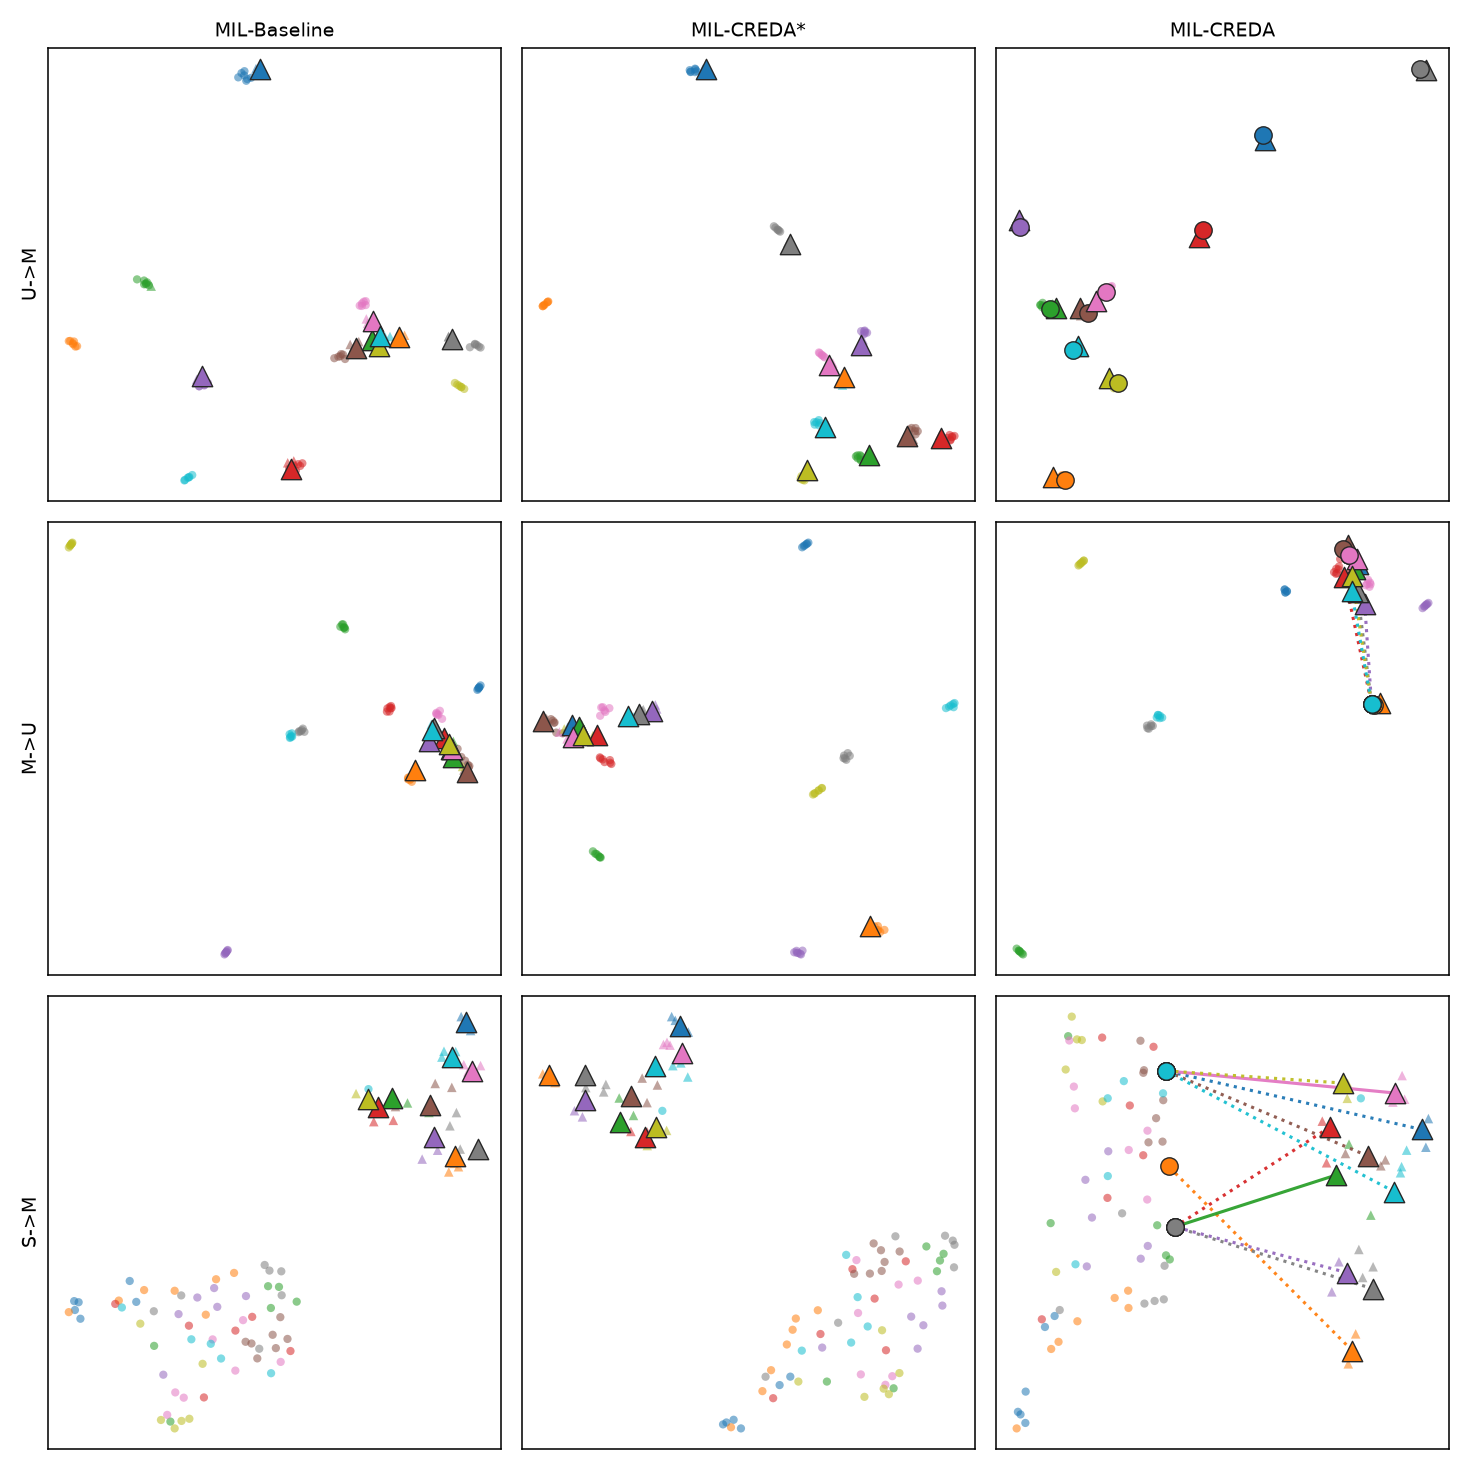

In [21]:
correspondencia = latent.correspondence_grid(
    config.RESULTS / "latent" / "correspondence.pdf", config.BAG_PANELS, transfers,
    seed, device)
display(figures.inline(correspondencia["figure"]))

### 5b · Los aciertos y la masa, como números

Los mismos paneles de arriba contados: de cuántas clases la vecina de fuente resultó
ser de la clase correcta, y cuánta masa de correspondencia cae en la clase verdadera.
Vivían dentro de la figura, como pie de cada panel, donde no se comparaban de una
fila a otra y de paso hacían que las tres columnas se vieran igual de afirmativas.
Cada método va etiquetado por lo que de verdad computa, así que se ve de un vistazo
cuál es el único que declara el término local. Buscamos que ese sea el que más
acierta, y por encima del azar de elegir una clase.

In [22]:
show(tables.objective("correspondence.massOnTrueClass"))

> **Buscamos que supere claramente 0.100**, que es el azar de una clase entre 10, y que suba más en el método que declara el término local que en el mismo método sin él. El máximo es 1.000.

In [23]:
show(tables.render_correspondence(correspondencia["scored"], markdown=True))

| Método | Qué computa | U->M | M->U | S->M | Masa prom. |
|---|---|---|---|---|---|
| `MIL-Baseline` | sin adaptación: solo fuente | 7/10 | 2/10 | 2/10 | **0.500** |
| `MIL-CREDA*` | adaptación milcreda, ponderada, sin término local | 9/10 | 3/10 | 2/10 | **0.519** |
| `MIL-CREDA` | adaptación milcreda, ponderada, con término local | 10/10 | 2/10 | 2/10 | **0.514** |

In [24]:
show(tables.conclusion_correspondence(correspondencia["scored"]))

Empatan sumando sus transferencias: MIL-CREDA*, MIL-CREDA. De acá no sale quién empareja mejor; el azar de acertar una clase es 0.100. El término local, aislado como MIL-CREDA contra MIL-CREDA*: las transferencias no coinciden — 1 a favor, 1 en contra, 1 planas (M->U -0.078, S->M +0.003, U->M +0.060). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

## 6 · La masa en la clase verdadera

Cuánta de la masa de correspondencia de cada bolsa de destino cae sobre bolsas de
fuente de su propia clase, promediada sobre todas las bolsas en vez de sobre los
pocos sujetos que la figura de arriba destaca. Es la afirmación propia del término
local, dicha como número: la figura muestra unos sujetos, esto mide todos. Buscamos
que suba claramente por encima del azar, y que suba
más en el método que declara el término que en el mismo método sin él.

In [25]:
show(tables.objective("correspondence.massOnTrueClass"))

> **Buscamos que supere claramente 0.100**, que es el azar de una clase entre 10, y que suba más en el método que declara el término local que en el mismo método sin él. El máximo es 1.000.

In [26]:
show(tables.render_readings(readings, "correspondence.massOnTrueClass",
                            f"masa en la clase verdadera "
                            f"(azar {1 / config.CLASSES:.3f})", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `MIL-CREDA` | 0.423 ± 0.000 | 0.851 ± 0.000 | 0.144 ± 0.000 | 0.268 ± 0.000 | 0.126 ± 0.000 | 0.201 ± 0.000 | **0.335** |
| `MIL-CREDA-U` | 0.236 ± 0.000 | 0.752 ± 0.000 | 0.100 ± 0.000 | 0.252 ± 0.000 | 0.171 ± 0.000 | 0.181 ± 0.000 | **0.282** |
| `MIL-CREDA-A` | 0.415 ± 0.000 | 0.612 ± 0.000 | 0.150 ± 0.000 | 0.168 ± 0.000 | 0.158 ± 0.000 | 0.184 ± 0.000 | **0.281** |
| `MIL-CREDA-K` | 0.508 ± 0.000 | 0.774 ± 0.000 | 0.174 ± 0.000 | 0.160 ± 0.000 | 0.177 ± 0.000 | 0.226 ± 0.000 | **0.337** |

In [27]:
show(tables.conclusion_mass(readings))

La masa más alta es la de **MIL-CREDA-K**, contra un azar de 0.100. MIL-CREDA supera el azar en 6 de 6 transferencias MIL-CREDA-U supera el azar en 5 de 6 transferencias MIL-CREDA-A supera el azar en 6 de 6 transferencias MIL-CREDA-K supera el azar en 6 de 6 transferencias Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

### 6b · Cuánto reparte la atención

La entropía de los pesos que la atención asigna dentro de una bolsa. Dice si la
bolsa se apoya en unas pocas instancias o las pesa a todas casi por igual, que es lo
que hace falta para saber si la masa de arriba viene de una correspondencia real o
de una atención que dejó de elegir. Es descriptivo: se informa y no se disputa, pero
una atención plana vuelve discutible cualquier lectura de la tabla anterior.

In [28]:
show(tables.objective("attentionSpread"))

> **Buscamos un valor lejos de 1.000.** La entropía está normalizada, así que 1.000 es la media uniforme: la atención dejó de elegir y cualquier lectura de la masa de arriba queda en duda. Es descriptivo, no se disputa, pero condiciona lo anterior.

In [29]:
show(tables.render_readings(readings, "attentionSpread",
                            "entropía de los pesos dentro de la bolsa", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `MIL-Baseline` | 0.710 ± 0.000 | 0.768 ± 0.000 | 0.609 ± 0.000 | 0.704 ± 0.000 | 0.785 ± 0.000 | 0.672 ± 0.000 | **0.708** |
| `MIL-CREDA**` | 0.695 ± 0.000 | 0.794 ± 0.000 | 0.638 ± 0.000 | 0.803 ± 0.000 | 0.824 ± 0.000 | 0.737 ± 0.000 | **0.749** |
| `MIL-CREDA*` | 0.679 ± 0.000 | 0.810 ± 0.000 | 0.586 ± 0.000 | 0.744 ± 0.000 | 0.822 ± 0.000 | 0.728 ± 0.000 | **0.728** |
| `MIL-CREDA` | 0.741 ± 0.000 | 0.849 ± 0.000 | 0.589 ± 0.000 | 0.777 ± 0.000 | 0.813 ± 0.000 | 0.758 ± 0.000 | **0.754** |
| `MIL-CREDA-U` | 0.691 ± 0.000 | 0.617 ± 0.000 | 0.714 ± 0.000 | 0.864 ± 0.000 | 0.616 ± 0.000 | 0.829 ± 0.000 | **0.722** |
| `MIL-CREDA-A` | 0.666 ± 0.000 | 0.684 ± 0.000 | 0.617 ± 0.000 | 0.766 ± 0.000 | 0.770 ± 0.000 | 0.761 ± 0.000 | **0.710** |
| `MIL-CREDA-K` | 0.814 ± 0.000 | 0.904 ± 0.000 | 0.775 ± 0.000 | 0.849 ± 0.000 | 0.902 ± 0.000 | 0.798 ± 0.000 | **0.840** |

In [30]:
show(tables.conclusion_attention(readings))

La entropía está normalizada, así que su máximo es uno y ahí la atención no estaría haciendo nada. Cómo quedó cada uno: MIL-Baseline reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA** reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA* reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA-U reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA-A reparte de forma desigual sin apoyarse en unas pocas MIL-CREDA-K reparte de forma desigual sin apoyarse en unas pocas Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

## 7 · El registro

Escribe `latent.json` con cada lectura, cada comparación contra el piso y cada
conclusión recalculada, y `latent.md` con las mismas tablas de arriba en el mismo
orden. Una sesión posterior tiene que poder saber que esta corrida ocurrió, bajo qué
reducción y contra qué revisión, y nada de eso vive fuera del repositorio. Se genera
junto con los resultados y nunca se escribe a mano: un resumen escrito a mano es una
segunda fuente de verdad, se desactualiza en silencio y se le cree igual.

In [31]:
# La comparación de cada método contra su propio piso ya no tiene sección en el
# cuaderno, y sigue siendo una medición que el registro tiene que llevar.
compared = latent.against_floor(readings)

output = config.RESULTS / "latent.json"
output.write_text(json.dumps({
    "revision": config.REVISION,
    "displaySeed": seed,
    "figureTransfers": transfers,
    "figureTransferRule": config.FIGURE_TRANSFER_RULE,
    "gridPanels": paneles,
    "gridUnit": config.LATENT_UNIT,
    "bagPanels": config.BAG_PANELS,
    "floorsAgree": {k: v for k, v in pisos.items() if k != "byTransfer"},
    "readings": readings,
    "againstFloor": compared,
    "correspondence": correspondencia["scored"],
    # Lo que midió la fase uno, copiado tal cual en la misma corrida que lo leyó.
    # Sin esto el registro no alcanza para volver a producir sus propias
    # conclusiones, y una conclusión que no se puede volver a calcular no se puede
    # comprobar contra nada.
    "reduction": summary["reduction"],
    "panorama": summary["panorama"],
    "conclusions": tables.conclusions({
        "runs": runs, "reduction": summary["reduction"],
        "panorama": summary["panorama"], "readings": readings,
        "correspondence": correspondencia["scored"],
    }),
    "figures": [str(grid_path.relative_to(REPOSITORY)),
                str(correspondencia["path"].relative_to(REPOSITORY))],
}, indent=2), encoding="utf-8")

(config.RESULTS / "latent.md").write_text("\n\n".join([
    f"# Fase dos — {config.REVISION}",
    tables.stamp(summary["reduction"], markdown=True),
    "## 1 · Razón entre distancias (más bajo es mejor, si la de entre clases no cayó)",
    tables.render_readings(readings, "geometry.ratio",
                           "razón: misma clase entre dominios / entre clases",
                           markdown=True),
    tables.conclusion_geometry(readings),
    "### 1b · Las dos distancias por separado (descriptivas, se leen juntas)",
    tables.render_readings(readings, "geometry.crossDomainSameClass",
                           "misma clase, entre los dos dominios", markdown=True),
    tables.render_readings(readings, "geometry.betweenClasses",
                           "clases distintas, dentro de un dominio", markdown=True),
    tables.conclusion_distances(readings),
    f"## 2 · Separabilidad de dominio (más cerca de {tables.DOMAIN_CHANCE:.3f} es mejor)",
    tables.render_readings(readings, "domainSeparability",
                           "exactitud de un clasificador de dominio", markdown=True),
    tables.conclusion_separability(readings),
    f"## 3 · Masa en la clase verdadera (más alto es mejor, azar {1 / config.CLASSES:.3f})",
    tables.render_readings(readings, "correspondence.massOnTrueClass",
                           "masa en la clase verdadera", markdown=True),
    tables.conclusion_mass(readings),
    "### 3b · Cuánto reparte la atención (descriptivo)",
    tables.render_readings(readings, "attentionSpread",
                           "entropía de los pesos dentro de la bolsa", markdown=True),
    tables.conclusion_attention(readings),
    "## 4 · La correspondencia, sujeto por sujeto",
    tables.render_correspondence(correspondencia["scored"], markdown=True),
    tables.conclusion_correspondence(correspondencia["scored"]),
]), encoding="utf-8")
print("escrito", output.relative_to(REPOSITORY))

escrito MIL-CREDA/Results/Benchmark/latent.json


In [32]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 ef8c1c8c07b40d9b368fa646b73e72e8c0c13ec88a77933816f87c509701fac3
